# Plug-and-play ADMM for Photocurrent Mapping image reconstruction

This notebook demonstrates Plug-and-Play (PnP) ADMM image reconstruction for
Photocurrent Mapping (PCM) data.

Starting from a high-resolution current map of a CIGS solar cell, subsampled
PCM measurements are simulated using the `PhotocurrentMapOp` operator. Several
reconstruction methods are then compared:

- Zero-filled pseudo-inverse reconstruction.
- Two compressed sensing baselines with a wavelet sparsity prior:
  FISTA with an $\ell_1$ penalty and SPGL1.
- PnP-ADMM with a pre-trained DRUNet denoiser as prior.

The goal is not to optimise performance, but to illustrate how
classical sparse reconstruction methods and PnP can be combined with the LION
operators for PCM.

## Setup

### Device configuration

Set the default device to a GPU if available. If multiple GPUs are present,
the desired GPU index can be specified here.

In [1]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

### Imports

Import the required libraries, including LION operators and reconstruction algorithms for PCM.

In [2]:
from datetime import datetime
from pathlib import Path
from typing import Callable

import deepinv
import matplotlib.pyplot as plt
import numpy as np
from jaxtyping import Float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from LION.classical_algorithms import fista_l1
from LION.classical_algorithms.spgl1_torch import spgl1_torch
from LION.operators import CompositeOp, Wavelet2D
from LION.operators.DebiasOp import debias_ls

# LION imports
from LION.operators.PhotocurrentMapOp import PhotocurrentMapOp, Subsampler
from LION.reconstructors.PnP import PnP

GrayscaleImage2D = Float[torch.Tensor, "height width"]
Measurement1D = Float[torch.Tensor, "num_measurements"]

### Define the data file paths

The example uses a single $256 \times 256$ current map of a CIGS solar cell
stored as a NumPy array. This image will serve as the ground truth in the
experiments.

In [3]:
data_dir = Path("/home/t/Documents/GIT/LION/data/photocurrent_data")
# data_dir = Path("your/path/to/photocurrent_data")

assert data_dir.exists(), f"Data directory {data_dir} does not exist."

cigs_filename = "example_CIGS_256x256.npy"

assert (data_dir / cigs_filename).exists(), f"Data file not found in {data_dir}."

### Set a directory to save logs and results

Each run is stored in a separate subdirectory named with the current date and
time, which makes it easier to keep track of different experiments.

In [4]:
current_datetime_str = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = Path("pcm_demo_output") / current_datetime_str
log_dir.mkdir(parents=True, exist_ok=True)

## Experiment

Define a general function to run the photocurrent mapping reconstruction using a reconstruction method.

The helper function `run_pcm_demo`:

- Builds the PCM operator and simulates subsampled measurements.
- Computes the zero-filled pseudo-inverse reconstruction.
- Runs a chosen reconstruction method given by `recon_fn`.
- Reports PSNR and SSIM for both reconstructions, displays and saves the images.

In [5]:
def run_pcm_demo(
    recon_method_name: str,
    recon_fn: Callable,
    ground_truth_image: GrayscaleImage2D,
    image_name: str,
    J: int,  # image size will be 2^J x 2^J
    subtract_from_J: int = 1,
    delta_divided_by: int = 4,
    log_dir: Path | str = ".",
    device: torch.device | str = "cuda:0",
):
    N = 1 << J
    im_tensor = torch.tensor(ground_truth_image).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    coarseJ = J - subtract_from_J
    delta = 1.0 / delta_divided_by

    sampling_percentage = delta * 100
    in_order_measurements_percentage = 1 / (1 << (subtract_from_J * 2)) * 100
    print(f"Sampling rate:         {sampling_percentage:.2f}%")
    print(f"In-order measurements: {in_order_measurements_percentage:.2f}%")

    subsampler = Subsampler(n=N * N, coarseJ=coarseJ, delta=delta)
    pcm_op = PhotocurrentMapOp(J=J, subsampler=subsampler, device=device)

    y_subsampled_tensor = pcm_op(im_tensor)
    zero_filled_recon_tensor = pcm_op.pseudo_inv(y_subsampled_tensor)

    im_np = im_tensor.squeeze().cpu().numpy()
    zero_filled_recon_np = zero_filled_recon_tensor.squeeze().cpu().numpy()

    recon_tensor = recon_fn(
        pcm_op=pcm_op,
        pcm_measurement=y_subsampled_tensor,
    )
    recon_np = recon_tensor.squeeze().cpu().numpy()

    data_range = im_np.max() - im_np.min()

    psnr_zf = psnr(im_np, zero_filled_recon_np, data_range=data_range)
    psnr_pnp = psnr(im_np, recon_np, data_range=data_range)

    ssim_zf = ssim(im_np, zero_filled_recon_np, data_range=data_range)
    ssim_pnp = ssim(im_np, recon_np, data_range=data_range)

    n_subplots = 4
    plt.figure(figsize=(n_subplots * 4, 4))

    plt.subplot(1, n_subplots, 1)
    plt.imshow(im_np, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, n_subplots, 2)
    plt.imshow(zero_filled_recon_np, cmap="gray")
    plt.title(
        f"Zero-filled Reconstruction\nPSNR: {psnr_zf:.2f} dB, SSIM: {ssim_zf:.4f}"
    )
    plt.axis("off")

    plt.subplot(1, n_subplots, 3)
    plt.imshow(recon_np, cmap="gray")
    plt.title(
        f"{recon_method_name} Reconstruction\nPSNR: {psnr_pnp:.2f} dB, SSIM: {ssim_pnp:.4f}"
    )
    plt.axis("off")

    plt.suptitle(
        "PCM Reconstructions Comparison\n"
        + f"sampling rate: {sampling_percentage:.2f}%, in-order measurements: {in_order_measurements_percentage:.2f}%",
        x=0.4,
        y=-0.05,
        fontsize=16,
    )

    plt.savefig(
        Path(log_dir)
        / f"{image_name}_{recon_method_name}_sampling_percentage={sampling_percentage:.2f}_in_order_measurements={in_order_measurements_percentage:.2f}.png",
        dpi=150,
    )

Load the data.

The array `cigs_raw_data` is a single 2D image representing the current map
of the CIGS device. This will be used as the ground truth image for all
reconstruction methods.

In [6]:
cigs_raw_data: GrayscaleImage2D = np.load(data_dir / cigs_filename)
print(f"CIGS data shape: {cigs_raw_data.shape}")

CIGS data shape: (256, 256)


In the examples below:

- `J = 8` so the image size is $2^J \times 2^J = 256 \times 256$.
- `delta_divided_by = 4` corresponds to a sampling rate
  $\delta = 1 / 4 = 0.25$, that is, 25% of the total measurements.
- `subtract_from_J = 2` keeps a central $2^{J-2} \times 2^{J-2} = 64 \times 64$
  block of in-order measurements, corresponding to 6.25% of the total;
  the remaining samples are taken in a compressed sensing fashion.

In [7]:
J = 8  # image size is 2^J x 2^J = 256x256
delta_divided_by = 4  # 25% sampling
subtract_from_J = (
    2  # keep 2^{J-2} x 2^{J-2} = 64x64 in-order measurements, or 6.25% of the total
)

## First experiment: PnP-ADMM on CIGS data

In this section the PCM PnP-ADMM algorithm is tested on the CIGS data.

Define the prior function using a pre-trained DRUNet denoiser and the
corresponding Plug-and-Play ADMM solver.

DRUNet is a deep convolutional denoiser proposed by:

> Kai Zhang, Yawei Li, Wangmeng Zuo, Lei Zhang, Luc Van Gool, and
> Radu Timofte, "Plug-and-Play Image Restoration with Deep Denoiser Prior,"
> IEEE Transactions on Pattern Analysis and Machine Intelligence, 44(10),
> 6360–6376, 2022.

In the PnP-ADMM framework, the proximal step of a regulariser is replaced by
an off-the-shelf denoiser. Here DRUNet acts as a powerful learned prior for
the PCM inverse problem, while the data fidelity term is handled by ADMM.

In [8]:
denoiser_DRUNet = deepinv.models.DRUNet(
    pretrained="download", in_channels=1, out_channels=1, device=device
)


def denoiser_fn(x: GrayscaleImage2D) -> GrayscaleImage2D:
    with torch.no_grad():
        return (
            denoiser_DRUNet(x.unsqueeze(0).unsqueeze(0), sigma=0.05)
            .squeeze(0)
            .squeeze(0)
        )


def run_pnp_admm(
    pcm_op: PhotocurrentMapOp,
    pcm_measurement: Measurement1D,
) -> GrayscaleImage2D:
    admm_iterations = 100
    admm_step_size = 1e5
    cg_max_iter = 100
    cg_tol = 1e-7

    print(
        f"Running PnP-ADMM reconstruction: {admm_iterations} iterations, cg_max_iter={cg_max_iter}..."
    )

    pnp = PnP(physics=pcm_op, prior_fn=denoiser_fn, algorithm="ADMM")
    return pnp.admm_algorithm(
        measurement=pcm_measurement,
        eta=admm_step_size,
        max_iter=admm_iterations,
        cg_max_iter=cg_max_iter,
        cg_tol=cg_tol,
    )

Sampling rate:         25.00%
In-order measurements: 6.25%
Running PnP-ADMM reconstruction: 100 iterations, cg_max_iter=100...


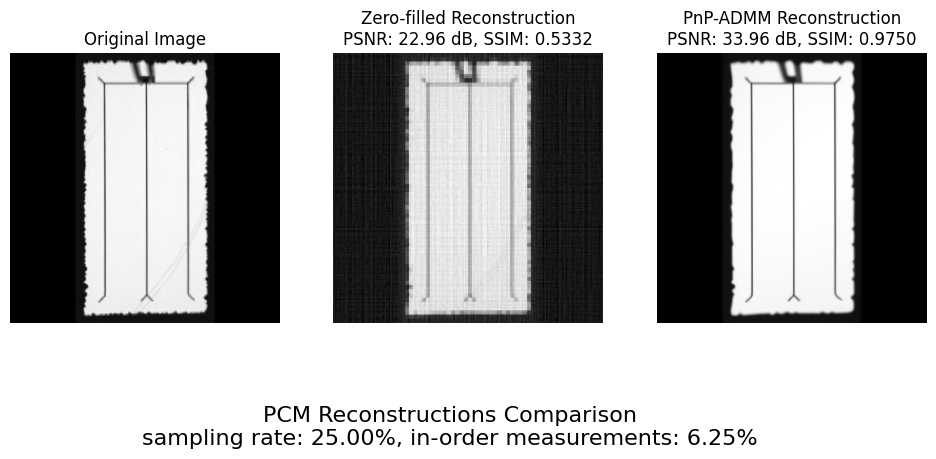

In [9]:
run_pcm_demo(
    recon_method_name="PnP-ADMM",
    recon_fn=run_pnp_admm,
    ground_truth_image=cigs_raw_data,
    image_name="cigs",
    J=8,  # image size is 2^J x 2^J = 256x256
    delta_divided_by=4,  # 25% sampling
    subtract_from_J=2,  # keep 2^{J-2} x 2^{J-2} = 64x64 in-order measurements, or 6.25% of the total
    log_dir=log_dir,
    device=device,
)

The code above runs the PnP-ADMM reconstruction and compares it to the
zero-filled pseudo-inverse.

Although PnP-ADMM substantially improves PSNR and SSIM, it can smooth out
fine-scale structures. In the context of defect detection, these small
features can be crucial, so high PSNR and SSIM alone are not sufficient to
guarantee that the reconstruction is fit for purpose.

In the next sections, two compressed sensing baselines with a wavelet
sparsity prior are explored and compared to the PnP-ADMM result.

## Compressed sensing baseline: FISTA with wavelet sparsity

This section applies FISTA with an $\ell_1$-penalty on wavelet coefficients
as a classical compressed sensing baseline.

Let $\Phi$ denote the PCM forward operator and $\Psi$ a 2D wavelet
transform with inverse $\Psi^{-1}$. The composite operator
$A = \Phi \Psi^{-1}$ acts on wavelet coefficients $w$.
FISTA approximately solves the standard $\ell_1$-regularised problem

$$
\min_w \frac{1}{2} \lVert A w - y \rVert_2^2
    + \lambda \lVert w \rVert_1,
$$

and the final current map is obtained as $x = \Psi^{-1} w$.

An optional debiasing step is included at the end to reduce the bias induced
by the $\ell_1$ penalty on the active support.

In [10]:
def run_fista_l1(
    pcm_op: PhotocurrentMapOp,
    pcm_measurement: Measurement1D,
) -> GrayscaleImage2D:

    lam = 10  # Good for Daubechies 4 wavelet transform
    max_iter = 1000
    tol = 1e-5

    debias_max_iter = 10  # TODO: Debiasing seems to not make much difference here
    debias_support_tol = 1e-5
    debias_tol = 1e-7

    height, width = pcm_op.domain_shape
    # Wavelet transform Psi
    wavelet = Wavelet2D((height, width), wavelet_name="db4", device=device)
    # Composite operator A = Phi Psi^{-1}
    A_op = CompositeOp(wavelet, pcm_op, device=device)

    print("Running FISTA reconstruction: " f"{max_iter} iterations, lambda={lam}...")
    w_hat = fista_l1(
        op=A_op,
        y=pcm_measurement,
        lam=lam,
        max_iter=max_iter,
        tol=tol,
        L=None,
        verbose=False,
        progress_bar=True,
    )

    # Optional debiasing
    print(f"Running debiasing: {debias_max_iter} iterations...")
    w_debias = debias_ls(
        op=A_op,
        y=pcm_measurement,
        w=w_hat,
        support_tol=debias_support_tol,
        max_iter=debias_max_iter,
        tol=debias_tol,
        progress_bar=True,
    )

    # Current map reconstruction
    cs_result_tensor = wavelet.inverse(w_debias)

    return cs_result_tensor

Sampling rate:         25.00%
In-order measurements: 6.25%
Running FISTA reconstruction: 1000 iterations, lambda=10...


FISTA l1:  86%|████████▌ | 855/1000 [00:02<00:00, 400.06it/s]


Running debiasing: 10 iterations...


Debiasing LS: 100%|██████████| 10/10 [00:00<00:00, 408.13it/s]


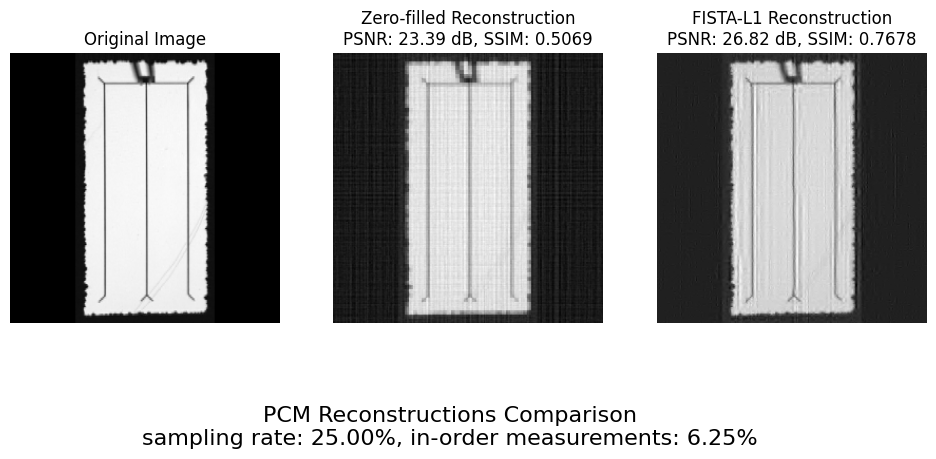

In [11]:
run_pcm_demo(
    recon_method_name="FISTA-L1",
    recon_fn=run_fista_l1,
    ground_truth_image=cigs_raw_data,
    image_name="cigs",
    J=8,  # image size is 2^J x 2^J = 256x256
    delta_divided_by=4,  # 25% sampling
    subtract_from_J=2,  # keep 2^{J-2} x 2^{J-2} = 64x64 in-order measurements, or 6.25% of the total
    log_dir=log_dir,
    device=device,
)

## Compressed sensing baseline: SPGL1 with wavelet sparsity

This section applies the SPGL1 algorithm as a second compressed sensing
baseline, again using a wavelet sparsity prior in the same setting
$A = \Phi \Psi^{-1}$.

SPGL1 is a spectral projected gradient method that efficiently solves
large-scale $\ell_1$-regularised problems and basis pursuit denoising
formulations. In this example it is run with default parameters suitable
for the PCM problem size, followed by the same optional debiasing step
used for FISTA.

In [12]:
def run_spgl1(
    pcm_op: PhotocurrentMapOp,
    pcm_measurement: Measurement1D,
) -> GrayscaleImage2D:

    lam: float = 1e-3
    max_iter = 1000
    tol: float = 1e-4
    debias_max_iter = 10
    debias_support_tol = 1e-5
    debias_tol = 1e-7

    height, width = pcm_op.domain_shape
    # Wavelet transform Psi
    wavelet = Wavelet2D((height, width), wavelet_name="db4", device=device)
    # Composite operator A = Phi Psi^{-1}
    A_op = CompositeOp(wavelet, pcm_op, device=device)

    print("Running SPGL1 reconstruction: " f"{max_iter} iterations, lambda={lam}...")
    w_hat = spgl1_torch(
        op=A_op,
        y=pcm_measurement,
        iter_lim=max_iter,
        verbosity=0,
        opt_tol=tol,
    )
    # Optional debiasing
    print(f"Running debiasing: {debias_max_iter} iterations...")
    w_debias = debias_ls(
        op=A_op,
        y=pcm_measurement,
        w=w_hat,
        support_tol=debias_support_tol,
        max_iter=debias_max_iter,
        tol=debias_tol,
        progress_bar=True,
    )

    # Current map reconstruction
    cs_result_tensor = wavelet.inverse(w_debias)

    return cs_result_tensor

Sampling rate:         25.00%
In-order measurements: 6.25%
Running SPGL1 reconstruction: 1000 iterations, lambda=0.001...


Linesearch failed with error 1. Damping max BB scaling to 10000.0
Linesearch failed with error 1. Damping max BB scaling to 1000.0
Linesearch failed with error 1. Damping max BB scaling to 100.0
Linesearch failed with error 1. Damping max BB scaling to 10.0
Linesearch failed with error 1. Damping max BB scaling to 1.0
Linesearch failed with error 1. Damping max BB scaling to 0.1
Linesearch failed with error 1. Damping max BB scaling to 0.01
Linesearch failed with error 1. Damping max BB scaling to 0.001
Linesearch failed with error 1. Damping max BB scaling to 0.0001
Linesearch failed with error 1. Damping max BB scaling to 1e-05


Running debiasing: 10 iterations...


Debiasing LS: 100%|██████████| 10/10 [00:00<00:00, 403.02it/s]


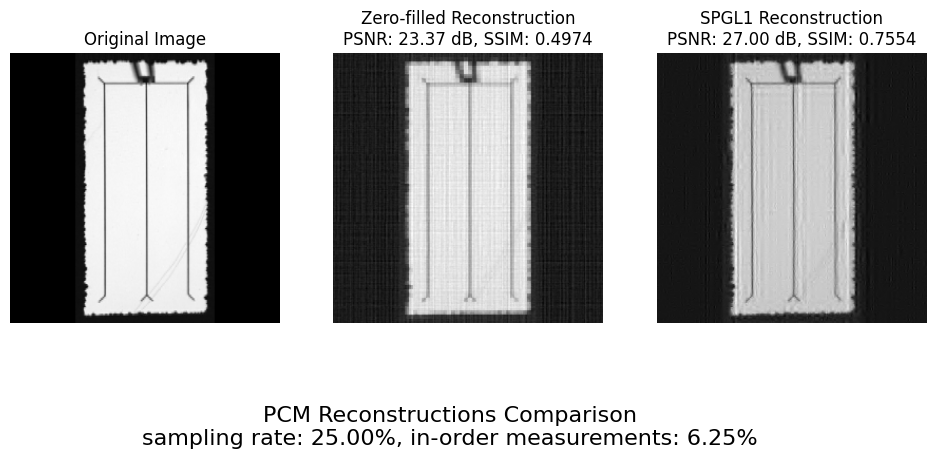

In [13]:
run_pcm_demo(
    recon_method_name="SPGL1",
    recon_fn=run_spgl1,
    ground_truth_image=cigs_raw_data,
    image_name="cigs",
    J=8,  # image size is 2^J x 2^J = 256x256
    delta_divided_by=4,  # 25% sampling
    subtract_from_J=2,  # keep 2^{J-2} x 2^{J-2} = 64x64 in-order measurements, or 6.25% of the total
    log_dir=log_dir,
    device=device,
)